In [27]:
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def find_project_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / "pyproject.toml").exists():
            return p
    raise RuntimeError("could not locate project root (no pyproject.toml found upward)")


PROJECT_ROOT = find_project_root(Path.cwd())
ENSEMBLE_ROOT = PROJECT_ROOT / "outputs" / "multitask" / "local_v2" / "ensemble"
MEMBERS_DIR = ENSEMBLE_ROOT / "members"
TARGETS = ["k_min", "k_max", "sigma", "beta"]

plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

print(f"Project root: {PROJECT_ROOT}")
print(f"Ensemble root: {ENSEMBLE_ROOT}")
assert ENSEMBLE_ROOT.is_dir(), (
    "outputs/multitask/local_v2/ensemble not found -- this ensemble is a large, "
    "gitignored local training run (see .gitignore); it must exist on disk to run this notebook."
)

Project root: c:\Users\sedig\Documents\cnn-turbulence
Ensemble root: c:\Users\sedig\Documents\cnn-turbulence\outputs\multitask\local_v2\ensemble


## 1. Ensemble configuration

In [28]:
member_dirs = sorted(p for p in MEMBERS_DIR.iterdir() if p.is_dir())
member_config = json.loads((member_dirs[0] / "configuration.json").read_text())
manifest = json.loads((member_dirs[0] / "data_manifest.json").read_text())

print("Ensemble members:", [p.name for p in member_dirs])
print()
print("Architecture:       ", member_config["model"]["architecture"])
print("Pretrained:         ", member_config["model"]["pretrained"])
print("Input channels:     ", member_config["model"]["in_channels"])
print("Input standardize:  ", member_config["model"]["input_standardization"])
print("Dropout:            ", member_config["model"]["dropout"])
print("Batch size:         ", member_config["optimization"]["batch_size"])
print("Learning rate:      ", member_config["optimization"]["learning_rate"])
print("Loss:               ", member_config["optimization"]["loss"])
print("Targets (multitask):", member_config["task"]["targets"])
print()
for split, info in manifest["splits"].items():
    print(f"{split:12s}: {info['total_samples']:>7,} samples  (128x128, post-kmax-fix pyFC data)")

Ensemble members: ['member_01_seed42', 'member_02_seed123', 'member_03_seed456', 'member_04_seed789', 'member_05_seed2026']

Architecture:        resnet34
Pretrained:          True
Input channels:      3
Input standardize:   imagenet
Dropout:             0.4
Batch size:          128
Learning rate:       0.001
Loss:                smooth_l1
Targets (multitask): ['k_min', 'k_max', 'sigma', 'beta']

test        :  50,000 samples  (128x128, post-kmax-fix pyFC data)
train       : 100,000 samples  (128x128, post-kmax-fix pyFC data)
validation  :  20,000 samples  (128x128, post-kmax-fix pyFC data)


## 2. Held-out test-set performance

In [29]:
metrics = json.loads((ENSEMBLE_ROOT / "evaluation" / "metrics" / "test_ensemble_metrics.json").read_text())

rows = []
for target in TARGETS:
    phys = metrics["per_target"][target]["physical"]
    rows.append({
        "target": target,
        "MAE": phys["mae"],
        "RMSE": phys["rmse"],
        "R2": phys["r2"],
        "Pearson": phys["pearson"],
    })
metrics_df = pd.DataFrame(rows).set_index("target")

# Loaded here (rather than in section 3) so the violin/bootstrap plot below can use
# per-image truth/prediction pairs, not just the aggregate metrics above.
predictions_path = ENSEMBLE_ROOT / "evaluation" / "predictions" / "test_per_image_predictions.csv"
predictions = pd.read_csv(predictions_path)

metrics_df

,MAE,RMSE,R2,Pearson
target,,,,
k_min,0.119058,0.152804,0.999710,0.999856
k_max,0.602372,1.238747,0.979488,0.989866
sigma,0.033855,0.045238,0.999013,0.999557
beta,0.111308,0.163114,0.920336,0.959616


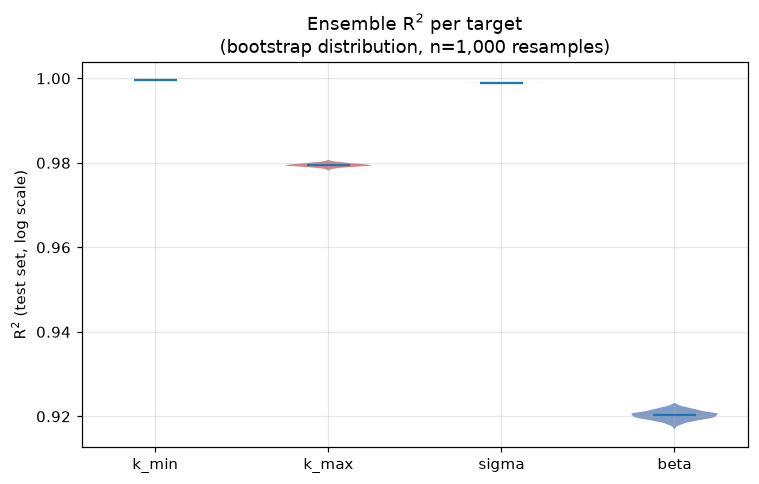

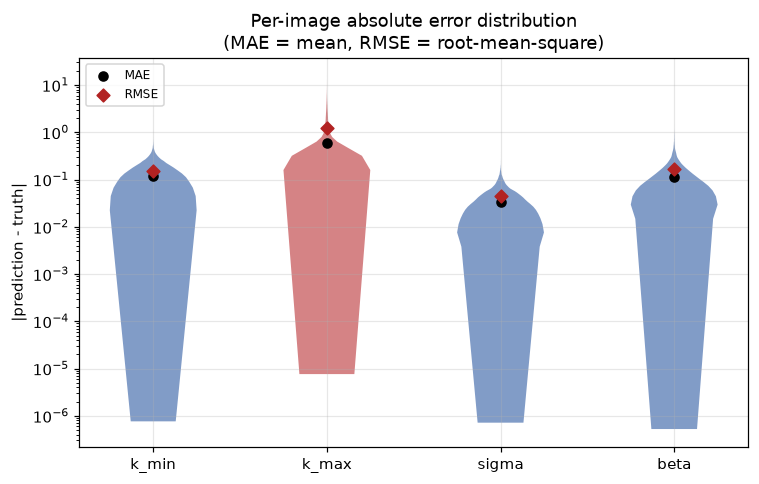

k_max R2 = 0.979 -- for comparison, every pre-fix modeling attempt (custom CNN, ResNet-50, DINOv2 ViT, weighted-loss deep ensemble; see docs/RESEARCH_JOURNEY.md phases 3-7) was capped around R2 0.69-0.81 by the unenforced pyFC spectral cutoff (docs/bugs/pyfc-kmax-not-enforced.md). This is the production confirmation that the fix holds end to end.

Bootstrap R2 (2.5-97.5 percentile) per target:
  k_min    R2 = 0.9997  [0.9997, 0.9997]
  k_max    R2 = 0.9795  [0.9787, 0.9803]
  sigma    R2 = 0.9990  [0.9990, 0.9990]
  beta     R2 = 0.9203  [0.9182, 0.9223]

Right-hand figure: the gap between the RMSE marker and the MAE marker on each violin shows how
much large outliers (vs. typical error) inflate that target's RMSE relative to its MAE.


In [53]:
def bootstrap_r2(truth, pred, n_boot=1000, seed=0):
    """Percentile-bootstrap distribution of R2 by resampling images with replacement."""
    truth = np.asarray(truth)
    pred = np.asarray(pred)
    n = len(truth)
    rng = np.random.default_rng(seed)
    boot = np.empty(n_boot)
    for i in range(n_boot):
        idx = rng.integers(0, n, n)
        t, p = truth[idx], pred[idx]
        ss_res = np.sum((t - p) ** 2)
        ss_tot = np.sum((t - t.mean()) ** 2)
        boot[i] = 1.0 - ss_res / ss_tot
    return boot


r2_boot = {
    target: bootstrap_r2(predictions[f"truth_{target}"], predictions[f"ensemble_mean_{target}"], seed=i)
    for i, target in enumerate(TARGETS)
}

colors = ["#4C72B0" if t != "k_max" else "#C44E52" for t in TARGETS]
positions = np.arange(1, len(TARGETS) + 1)

# --- Figure 1: bootstrap R2 distribution (log-scale y-axis) ---
fig1, ax1 = plt.subplots(figsize=(7, 4.5))
parts = ax1.violinplot(
    [r2_boot[t] for t in TARGETS], positions=positions, showmeans=True, showextrema=False,
)
for pc, c in zip(parts["bodies"], colors):
    pc.set_facecolor(c)
    pc.set_alpha(0.7)
ax1.set_xticks(positions)
ax1.set_xticklabels(TARGETS)
ax1.set_ylabel("R$^2$ (test set, log scale)")
ax1.set_title(f"Ensemble R$^2$ per target\n(bootstrap distribution, n={next(iter(r2_boot.values())).size:,} resamples)")
plt.tight_layout()
plt.show()

# --- Figure 2: per-image absolute error distribution (log-scale y-axis) ---
fig2, ax2 = plt.subplots(figsize=(7, 4.5))
err_data = [predictions[f"absolute_error_{t}"].values for t in TARGETS]
parts2 = ax2.violinplot(err_data, positions=positions, showmeans=False, showextrema=False)
for pc, c in zip(parts2["bodies"], colors):
    pc.set_facecolor(c)
    pc.set_alpha(0.7)
for i, target in zip(positions, TARGETS):
    ax2.scatter(
        i, metrics_df.loc[target, "MAE"], marker="o", color="black", zorder=3, s=35,
        label="MAE" if i == 1 else None,
    )
    ax2.scatter(
        i, metrics_df.loc[target, "RMSE"], marker="D", color="firebrick", zorder=3, s=35,
        label="RMSE" if i == 1 else None,
    )
ax2.set_yscale("log")
ax2.set_xticks(positions)
ax2.set_xticklabels(TARGETS)
ax2.set_ylabel("|prediction - truth|")
ax2.set_title("Per-image absolute error distribution\n(MAE = mean, RMSE = root-mean-square)")
ax2.legend(loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

print(
    f"k_max R2 = {metrics_df.loc['k_max', 'R2']:.3f} -- for comparison, every pre-fix modeling "
    "attempt (custom CNN, ResNet-50, DINOv2 ViT, weighted-loss deep ensemble; see "
    "docs/RESEARCH_JOURNEY.md phases 3-7) was capped around R2 0.69-0.81 by the unenforced pyFC "
    "spectral cutoff (docs/bugs/pyfc-kmax-not-enforced.md). This is the production confirmation "
    "that the fix holds end to end."
)
print()
print("Bootstrap R2 (2.5-97.5 percentile) per target:")
for target in TARGETS:
    lo, hi = np.percentile(r2_boot[target], [2.5, 97.5])
    print(f"  {target:8s} R2 = {metrics_df.loc[target, 'R2']:.4f}  [{lo:.4f}, {hi:.4f}]")
print()
print("Right-hand figure: the gap between the RMSE marker and the MAE marker on each violin shows how")
print("much large outliers (vs. typical error) inflate that target's RMSE relative to its MAE.")

## 3. Predictions vs. truth (held-out test set)

In [31]:
print(f"{len(predictions):,} test-set predictions loaded (in section 2 above, so the bootstrap/violin plot there could use them)")
predictions.head()

50,000 test-set predictions loaded (in section 2 above, so the bootstrap/violin plot there could use them)


,sample_index,sample_key,truth_k_min,ensemble_mean_k_min,ensemble_sd_k_min,absolute_error_k_min,prediction_member_01_seed42_k_min,prediction_member_02_seed123_k_min,prediction_member_03_seed456_k_min,prediction_member_04_seed789_k_min,...,prediction_member_05_seed2026_sigma,truth_beta,ensemble_mean_beta,ensemble_sd_beta,absolute_error_beta,prediction_member_01_seed42_beta,prediction_member_02_seed123_beta,prediction_member_03_seed456_beta,prediction_member_04_seed789_beta,prediction_member_05_seed2026_beta
0,0,test/flat_4param_128x128_50000_disjoint_test.h...,14.531979,14.759277,0.049917,0.227299,14.713867,14.759277,14.706299,14.797119,...,2.524414,-1.832108,-1.716797,0.035433,0.115311,-1.724609,-1.688477,-1.750000,-1.671875,-1.749023
1,1,test/flat_4param_128x128_50000_disjoint_test.h...,11.170468,11.059863,0.067566,0.110605,10.990234,11.171875,11.035645,11.043213,...,2.749023,-1.651597,-1.664844,0.024054,0.013246,-1.696289,-1.664062,-1.653320,-1.677734,-1.632812
2,2,test/flat_4param_128x128_50000_disjoint_test.h...,14.055305,14.006982,0.191361,0.048322,14.131104,14.002441,13.677002,14.115967,...,0.966797,-1.189288,-1.281055,0.035877,0.091766,-1.342773,-1.279297,-1.257812,-1.254883,-1.270508
3,3,test/flat_4param_128x128_50000_disjoint_test.h...,7.021431,6.790552,0.009423,0.230880,6.793579,6.782227,6.804932,6.789795,...,1.194458,-2.732531,-2.732715,0.051465,0.000184,-2.719482,-2.743652,-2.800049,-2.742920,-2.657471
4,4,test/flat_4param_128x128_50000_disjoint_test.h...,9.656552,9.841357,0.107220,0.184805,9.741455,9.749023,9.907959,9.991211,...,4.816895,-2.773717,-2.665430,0.070328,0.108287,-2.745605,-2.732422,-2.584473,-2.640137,-2.624512


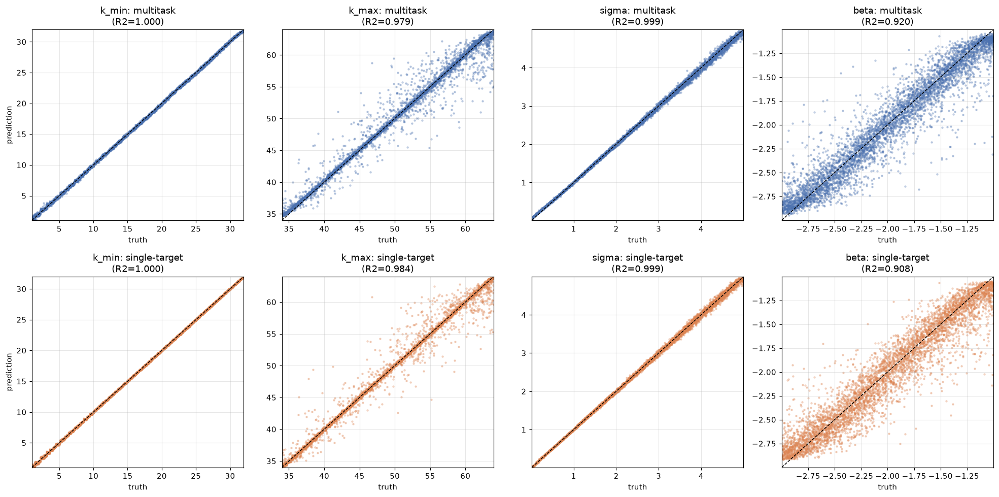

Same held-out test images (n=5,000 of 50,000), same axis range per column, top row = multitask ensemble, bottom row = the dedicated single-target ensemble for that parameter (both plotted as their ensemble mean). See section 8 for the full statistical comparison (paired significance test + training cost) behind these per-target R2 differences.


In [32]:
def r2_score(truth, pred):
    truth = np.asarray(truth)
    pred = np.asarray(pred)
    ss_res = np.sum((truth - pred) ** 2)
    ss_tot = np.sum((truth - truth.mean()) ** 2)
    return 1.0 - ss_res / ss_tot


rng = np.random.default_rng(0)
plot_idx = rng.choice(len(predictions), size=5000, replace=False)
sample = predictions.iloc[plot_idx]

single_r2, single_sample_pred = {}, {}
for target in TARGETS:
    single_path = (
        PROJECT_ROOT / "outputs" / f"single_{target}" / "local_v2" / "ensemble"
        / "evaluation" / "predictions" / "test_per_image_predictions.csv"
    )
    single_full = pd.read_csv(single_path)[["sample_key", f"ensemble_mean_{target}"]].rename(
        columns={f"ensemble_mean_{target}": "pred_single"}
    )
    merged_full = predictions[["sample_key", f"truth_{target}"]].merge(single_full, on="sample_key")
    single_r2[target] = r2_score(merged_full[f"truth_{target}"], merged_full["pred_single"])
    single_sample_pred[target] = sample[["sample_key"]].merge(
        single_full, on="sample_key", how="left"
    )["pred_single"].values

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
approaches = [
    ("multitask", "#4C72B0", metrics_df["R2"], lambda t: sample[f"ensemble_mean_{t}"]),
    ("single-target", "#DD8452", pd.Series(single_r2), lambda t: single_sample_pred[t]),
]
for col, target in enumerate(TARGETS):
    truth = sample[f"truth_{target}"]
    pred_multitask = sample[f"ensemble_mean_{target}"]
    pred_single = single_sample_pred[target]
    lo = min(truth.min(), pred_multitask.min(), pred_single.min())
    hi = max(truth.max(), pred_multitask.max(), pred_single.max())
    for row, (label, color, r2_lookup, pred_fn) in enumerate(approaches):
        ax = axes[row, col]
        ax.scatter(truth, pred_fn(target), s=4, alpha=0.3, color=color)
        ax.plot([lo, hi], [lo, hi], color="black", lw=1, ls="--")
        ax.set_xlim(lo, hi)
        ax.set_ylim(lo, hi)
        ax.set_title(f"{target}: {label}\n(R2={r2_lookup[target]:.3f})")
        ax.set_xlabel("truth")
        if col == 0:
            ax.set_ylabel("prediction")
plt.tight_layout()
plt.show()

print(
    f"Same held-out test images (n=5,000 of {len(predictions):,}), same axis range per column, top "
    "row = multitask ensemble, bottom row = the dedicated single-target ensemble for that parameter "
    "(both plotted as their ensemble mean). See section 8 for the full statistical comparison (paired "
    "significance test + training cost) behind these per-target R2 differences."
)

## 4. Residuals

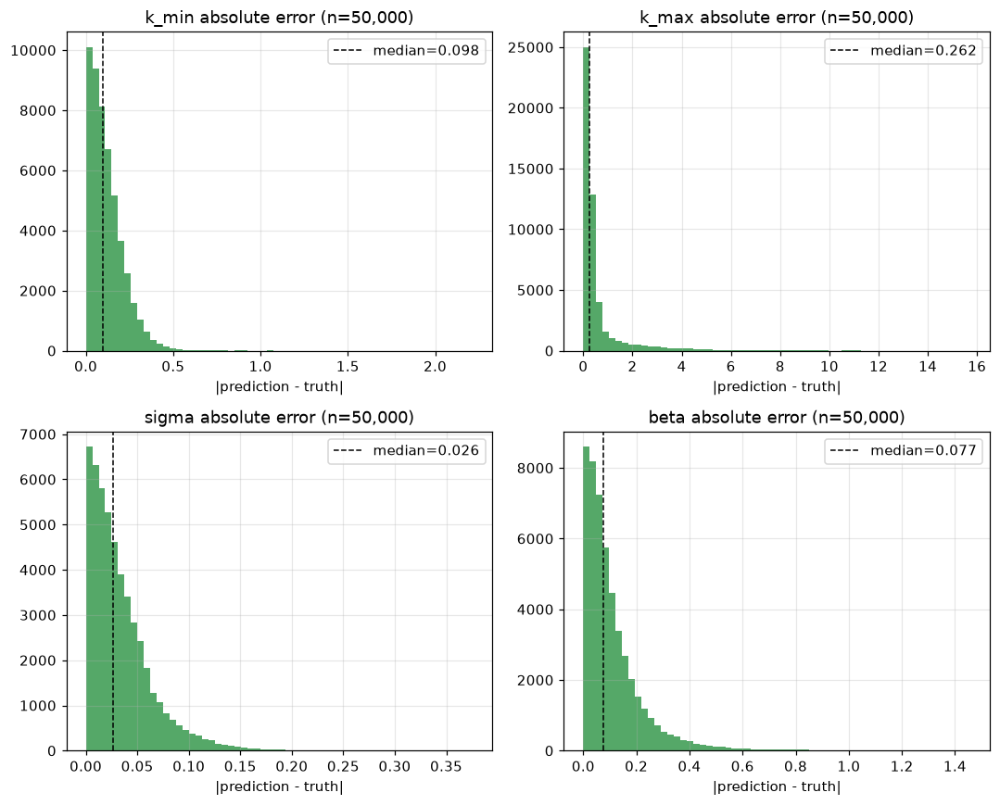

In [33]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for ax, target in zip(axes.ravel(), TARGETS):
    err = predictions[f"absolute_error_{target}"]
    ax.hist(err, bins=60, color="#55A868")
    ax.axvline(err.median(), color="black", lw=1, ls="--", label=f"median={err.median():.3f}")
    ax.set_title(f"{target} absolute error (n={len(err):,})")
    ax.set_xlabel("|prediction - truth|")
    ax.legend()
plt.tight_layout()
plt.show()

### 4.1 Residuals vs. truth value

Same predictions as above, but plotted against the true parameter value instead of collapsed into one histogram -- this checks whether the error is roughly homogeneous across each parameter's range, or concentrated at particular values (e.g. near a boundary).

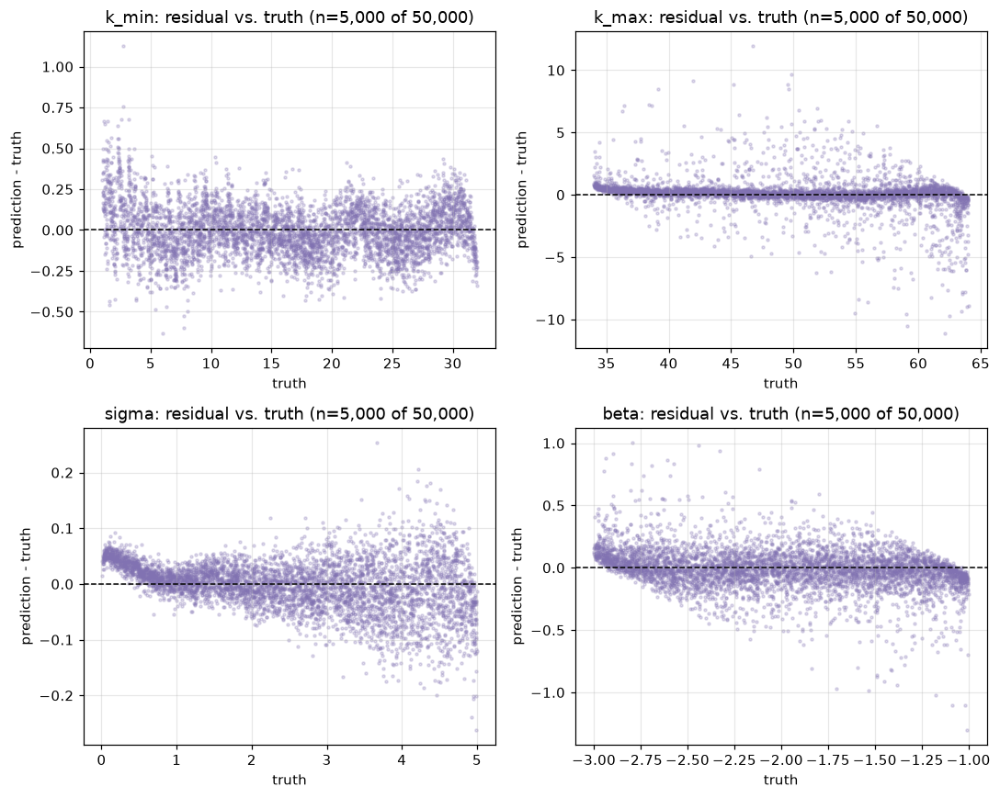

RMSE by truth-value tercile (full test set, n=50,000):
  k_min   : low=0.180, mid=0.136, high=0.138
  k_max   : low=0.851, mid=1.247, high=1.525
  sigma   : low=0.029, mid=0.035, high=0.064
  beta    : low=0.155, mid=0.162, high=0.172

high-tercile / low-tercile RMSE ratio (>1.3x flagged as error growing with the parameter's value):
  k_min   : 0.77x <- roughly homogeneous
  k_max   : 1.79x <- error grows with truth value
  sigma   : 2.16x <- error grows with truth value
  beta    : 1.11x <- roughly homogeneous


In [34]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for ax, target in zip(axes.ravel(), TARGETS):
    truth = sample[f"truth_{target}"]
    residual = sample[f"ensemble_mean_{target}"] - truth
    ax.scatter(truth, residual, s=4, alpha=0.25, color="#8172B2")
    ax.axhline(0, color="black", lw=1, ls="--")
    ax.set_title(f"{target}: residual vs. truth (n=5,000 of {len(predictions):,})")
    ax.set_xlabel("truth")
    ax.set_ylabel("prediction - truth")
plt.tight_layout()
plt.show()

print(f"RMSE by truth-value tercile (full test set, n={len(predictions):,}):")
tercile_rmse = {}
for target in TARGETS:
    truth = predictions[f"truth_{target}"]
    residual = predictions[f"ensemble_mean_{target}"] - truth
    terciles = pd.qcut(truth, 3, labels=["low", "mid", "high"])
    rmse_by_tercile = residual.groupby(terciles, observed=True).apply(lambda r: np.sqrt(np.mean(r ** 2)))
    tercile_rmse[target] = rmse_by_tercile
    print(f"  {target:8s}: " + ", ".join(f"{k}={v:.3f}" for k, v in rmse_by_tercile.items()))

print()
print("high-tercile / low-tercile RMSE ratio (>1.3x flagged as error growing with the parameter's value):")
for target in TARGETS:
    ratio = tercile_rmse[target]["high"] / tercile_rmse[target]["low"]
    flag = " <- error grows with truth value" if ratio > 1.3 else " <- roughly homogeneous"
    print(f"  {target:8s}: {ratio:.2f}x{flag}")

## 5. Uncertainty calibration

Does the ensemble's epistemic spread (member-to-member standard deviation) actually track where it's wrong? A well-calibrated ensemble should show higher spread on higher-error predictions -- a positive correlation here is the signal that `epistemic_std` is a useful per-prediction trust signal, not just noise.

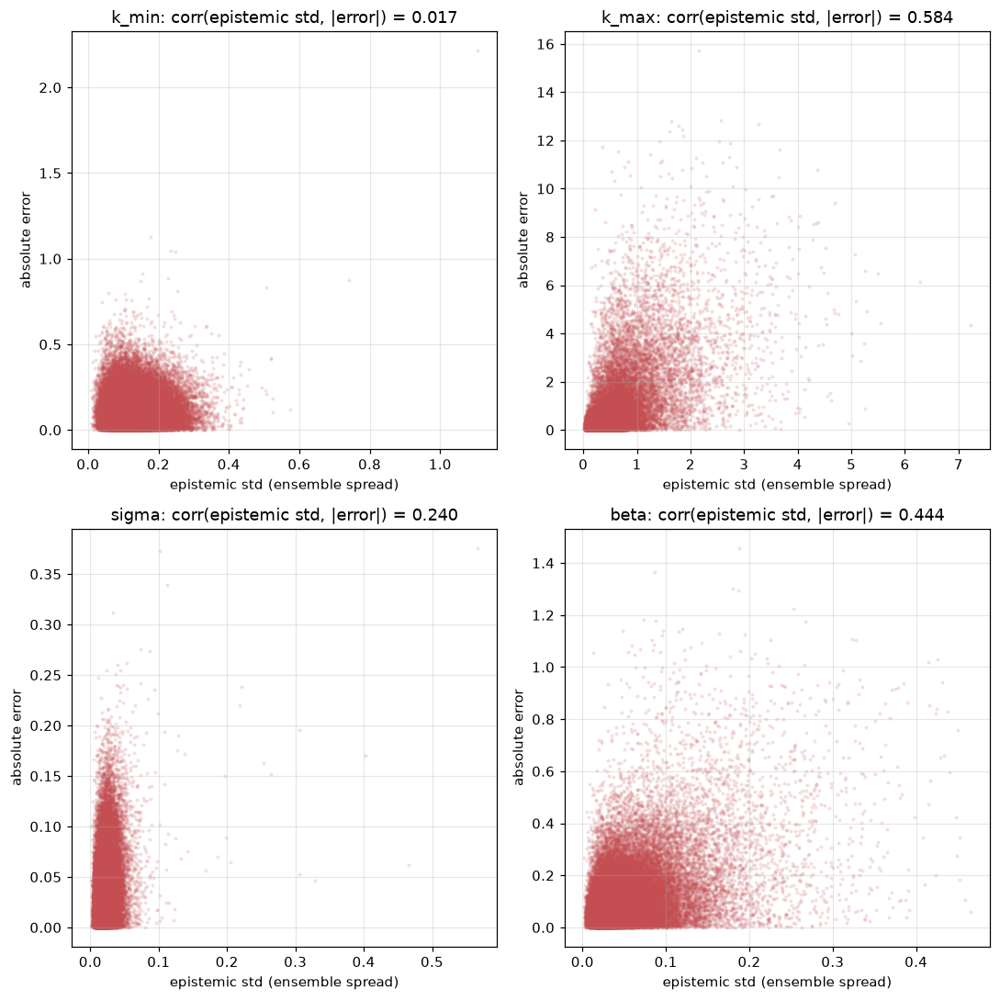

In [35]:
fig, axes = plt.subplots(2, 2, figsize=(10, 10))
for ax, target in zip(axes.ravel(), TARGETS):
    sd = predictions[f"ensemble_sd_{target}"]
    err = predictions[f"absolute_error_{target}"]
    corr = np.corrcoef(sd, err)[0, 1]
    ax.scatter(sd, err, s=3, alpha=0.12, color="#C44E52")
    ax.set_title(f"{target}: corr(epistemic std, |error|) = {corr:.3f}")
    ax.set_xlabel("epistemic std (ensemble spread)")
    ax.set_ylabel("absolute error")
plt.tight_layout()
plt.show()

## 6. Learned representation structure

The training pipeline's `interpretability` stage fits PCA, CCA, and UMAP on the shared 256-d representation (the layer feeding all four regression heads), using validation embeddings, then projects held-out test embeddings into those axes. This asks: does the network's internal representation actually organize itself by the physical parameters it's predicting -- and if so, can we read off *which part* of the representation encodes *which* parameter, and does the embedding suggest distinct turbulence regimes?

**What "consensus" means below (6.2-6.5):** each of the 5 ensemble members has its own 256-d shared embedding, and these aren't directly comparable to each other -- independently trained networks can differ by rotations, sign flips, and permutations, so simply averaging the 5 raw embeddings would wash out real structure. Instead, each member's embedding is standardized independently (`StandardScaler` fit on validation embeddings) and then concatenated across all 5 members into one 5x256 = 1280-d joint space (`turbulens/training/interpret_embeddings.py`; see `.../interpretability/shared/consensus_representation.json`), and PCA/UMAP below are fit on *that* 1280-d space. So the correlation matrix (6.2) and gradient plots (6.3) reflect all 5 ensemble members jointly -- not any single model's embedding.

Subsections: 6.1 how many PCA components matter, 6.2 which components encode which parameter (correlation-based), 6.3 per-target gradient plots on each parameter's own best axes, 6.4 clustering the embedding into candidate regimes, 6.5 one interactive explorer over all of it, then the existing CCA check.

In [36]:
interp_dir = ENSEMBLE_ROOT / "interpretability" / "shared" / "representations" / "consensus"
pca_coords = np.load(interp_dir / "pca_coordinates.npz")["test"]
umap_coords = np.load(interp_dir / "umap_coordinates.npz")["test"]
n_pcs = pca_coords.shape[1]
pc_cols = [f"PC{i + 1}" for i in range(n_pcs)]

embeddings_path = ENSEMBLE_ROOT / "interpretability" / "shared" / "embeddings" / f"{member_dirs[0].name}.npz"
sample_keys = np.load(embeddings_path)["test_sample_key"]

interp_df = pd.DataFrame({
    "sample_key": sample_keys,
    **{col: pca_coords[:, i] for i, col in enumerate(pc_cols)},
    "UMAP1": umap_coords[:, 0],
    "UMAP2": umap_coords[:, 1],
})
interp_df = interp_df.merge(
    predictions[["sample_key"] + [f"truth_{t}" for t in TARGETS] + [f"ensemble_mean_{t}" for t in TARGETS]],
    on="sample_key", how="left",
)
print(f"{len(interp_df):,} test embeddings matched to truth labels via sample_key ({n_pcs} PCA components retained)")
interp_df.head()

50,000 test embeddings matched to truth labels via sample_key (20 PCA components retained)


,sample_key,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,...,UMAP1,UMAP2,truth_k_min,truth_k_max,truth_sigma,truth_beta,ensemble_mean_k_min,ensemble_mean_k_max,ensemble_mean_sigma,ensemble_mean_beta
0,test/flat_4param_128x128_50000_disjoint_test.h...,9.292376,-0.787444,-10.291351,-3.450857,18.616898,11.793402,4.110932,2.845229,-1.756467,...,4.747626,4.017895,14.531979,49.462132,2.518375,-1.832108,14.759277,49.098145,2.511230,-1.716797
1,test/flat_4param_128x128_50000_disjoint_test.h...,6.330178,10.987706,-12.024483,-17.953117,5.285560,11.805382,-15.463538,1.729536,8.925192,...,3.023968,3.532523,11.170468,62.263783,2.770725,-1.651597,11.059863,62.400391,2.768066,-1.664844
2,test/flat_4param_128x128_50000_disjoint_test.h...,-16.861031,-5.338108,-12.518865,17.626862,3.245443,12.974347,1.414678,-4.718148,1.294425,...,5.016318,9.499936,14.055305,40.370090,0.932032,-1.189288,14.006982,40.882568,0.968506,-1.281055
3,test/flat_4param_128x128_50000_disjoint_test.h...,-21.060867,15.002779,17.866718,-14.369330,1.213447,-5.287867,-2.092916,1.074455,0.625814,...,2.830817,2.054507,7.021431,57.235821,1.199133,-2.732531,6.790552,57.030273,1.197632,-2.732715
4,test/flat_4param_128x128_50000_disjoint_test.h...,14.102242,20.646078,19.698193,-11.986861,-10.435427,9.325545,5.322855,2.260681,5.699270,...,4.846137,5.901357,9.656552,56.205559,4.732774,-2.773717,9.841357,56.160156,4.794434,-2.665430


### 6.1 How many PCA components matter?

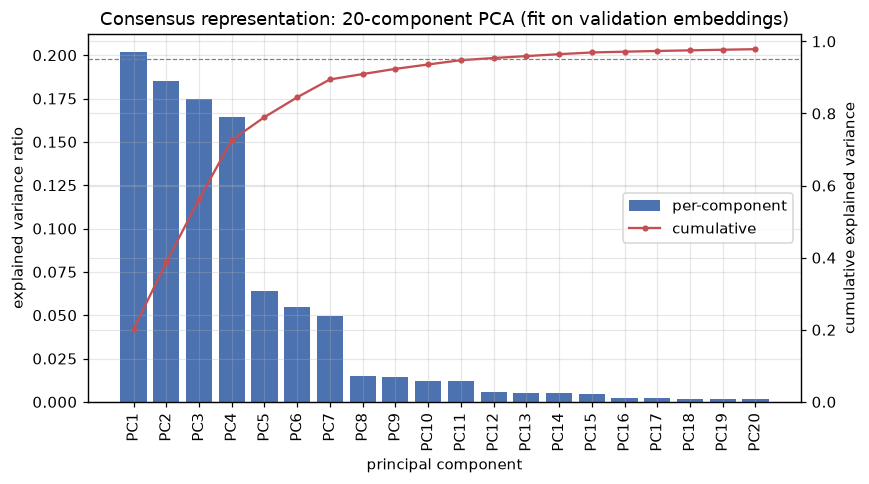

First 4 PCs explain 72.6% of variance; 12 PCs needed to reach 95%.


In [37]:
explained = pd.read_csv(interp_dir / "pca_explained_variance.csv")

fig, ax1 = plt.subplots(figsize=(8, 4.5))
ax1.bar(explained["component"], explained["explained_variance_ratio"], color="#4C72B0", label="per-component")
ax1.set_ylabel("explained variance ratio")
ax1.set_xlabel("principal component")
ax1.tick_params(axis="x", rotation=90)

ax2 = ax1.twinx()
ax2.plot(explained["component"], explained["cumulative_variance"], color="#C44E52", marker="o", ms=3, label="cumulative")
ax2.set_ylabel("cumulative explained variance")
ax2.set_ylim(0, 1.02)
ax2.axhline(0.95, color="gray", lw=0.8, ls="--")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="center right")
plt.title(f"Consensus representation: {n_pcs}-component PCA (fit on validation embeddings)")
plt.tight_layout()
plt.show()

n_for_95 = int((explained["cumulative_variance"] >= 0.95).idxmax()) + 1
print(
    f"First 4 PCs explain {explained['cumulative_variance'].iloc[3]:.1%} of variance; "
    f"{n_for_95} PCs needed to reach 95%."
)

### 6.2 Which components encode which parameter?

Pearson correlation between every retained PC and each target's true value (test split). This is the "identify all the PCs that codify each variable" question, made explicit rather than assumed from a fixed PC1/PC2 view.

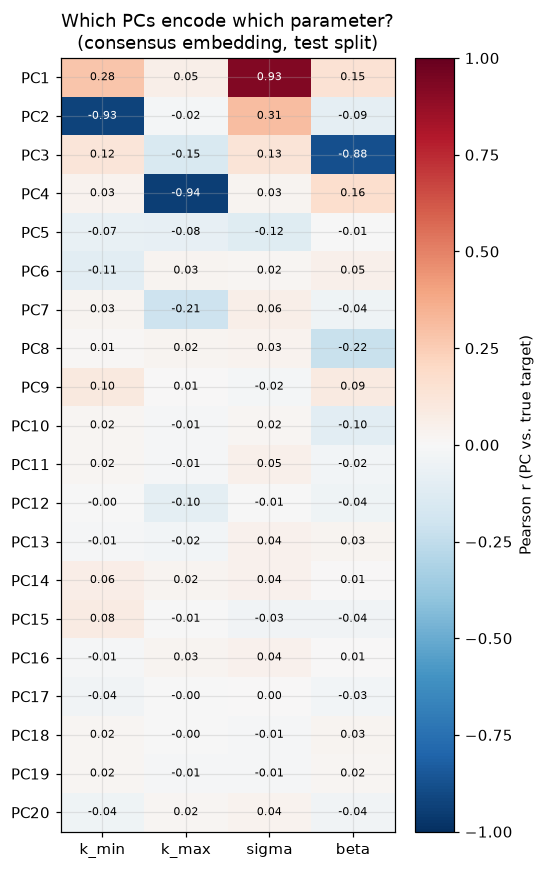

Best-correlated PC per target:
  k_min    -> PC2  (r = -0.926)
  k_max    -> PC4  (r = -0.941)
  sigma    -> PC1  (r = +0.926)
  beta     -> PC3  (r = -0.879)


In [38]:
corr_rows = []
for pc in pc_cols:
    for target in TARGETS:
        corr_rows.append({
            "component": pc,
            "target": target,
            "pearson": np.corrcoef(interp_df[pc], interp_df[f"truth_{target}"])[0, 1],
        })
corr_df = pd.DataFrame(corr_rows)
corr_pivot = corr_df.pivot(index="component", columns="target", values="pearson").reindex(pc_cols)[TARGETS]

fig, ax = plt.subplots(figsize=(5, 8))
im = ax.imshow(corr_pivot.values, cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")
ax.set_xticks(range(len(TARGETS)))
ax.set_xticklabels(TARGETS)
ax.set_yticks(range(len(pc_cols)))
ax.set_yticklabels(pc_cols)
for i in range(len(pc_cols)):
    for j in range(len(TARGETS)):
        ax.text(
            j, i, f"{corr_pivot.values[i, j]:.2f}", ha="center", va="center",
            color="white" if abs(corr_pivot.values[i, j]) > 0.5 else "black", fontsize=7,
        )
plt.colorbar(im, ax=ax, label="Pearson r (PC vs. true target)")
ax.set_title("Which PCs encode which parameter?\n(consensus embedding, test split)")
plt.tight_layout()
plt.show()

best_pc = corr_pivot.abs().idxmax(axis=0)
print("Best-correlated PC per target:")
for target in TARGETS:
    pc = best_pc[target]
    print(f"  {target:8s} -> {pc}  (r = {corr_pivot.loc[pc, target]:+.3f})")

### 6.3 Consensus gradient plots, per target

Instead of a fixed PC1-vs-PC2 view, each panel below plots the embedding on *that target's own* top-2 correlated PCs from 6.2, colored by the true value -- a "consensus plot" that should show a clean gradient if the representation encodes that parameter well.

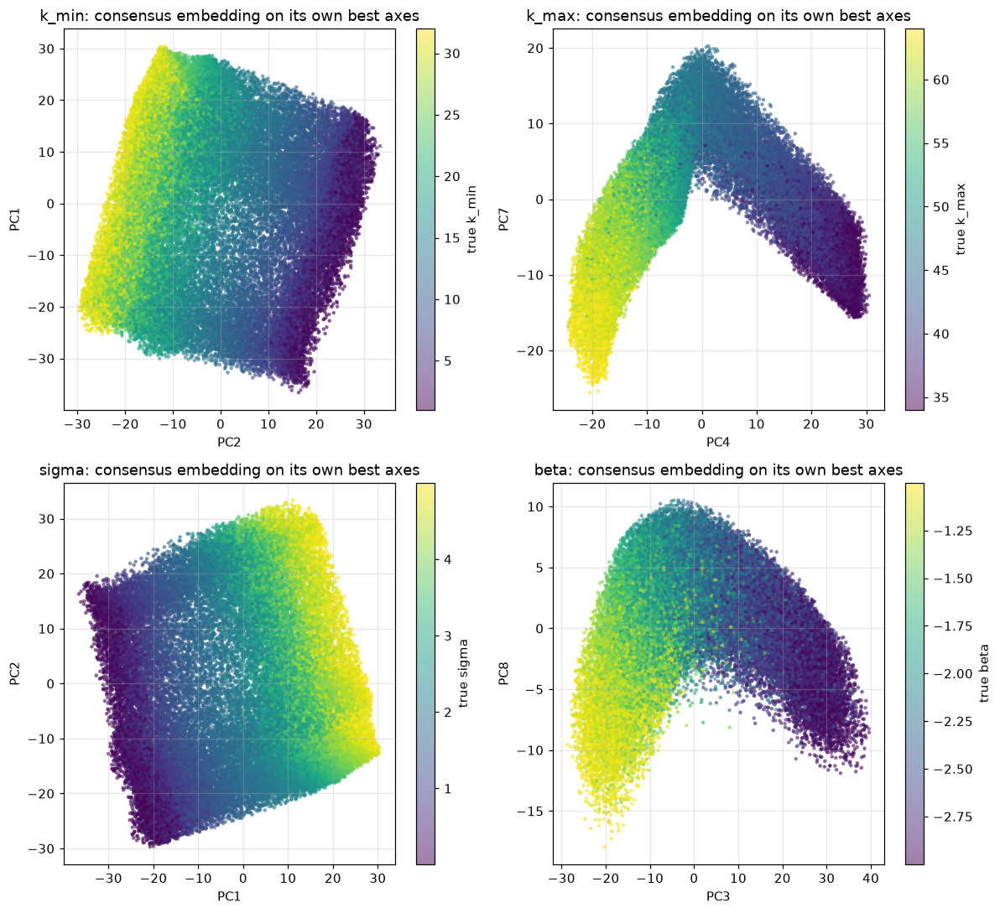

Each panel uses that target's own top-2 correlated PCs (not a fixed PC1/PC2) -- the smooth, one-directional gradients confirm the network encodes each parameter nearly linearly along its own representation axis, largely disentangled from the other three.


In [39]:
top2_pcs = {
    target: corr_pivot[target].abs().sort_values(ascending=False).index[:2].tolist()
    for target in TARGETS
}

fig, axes = plt.subplots(2, 2, figsize=(11, 10))
for ax, target in zip(axes.ravel(), TARGETS):
    pc_x, pc_y = top2_pcs[target]
    sc = ax.scatter(
        interp_df[pc_x], interp_df[pc_y], c=interp_df[f"truth_{target}"],
        s=4, alpha=0.5, cmap="viridis",
    )
    plt.colorbar(sc, ax=ax, label=f"true {target}")
    ax.set_title(f"{target}: consensus embedding on its own best axes")
    ax.set_xlabel(pc_x)
    ax.set_ylabel(pc_y)
plt.tight_layout()
plt.show()

print(
    "Each panel uses that target's own top-2 correlated PCs (not a fixed PC1/PC2) -- the smooth, "
    "one-directional gradients confirm the network encodes each parameter nearly linearly along "
    "its own representation axis, largely disentangled from the other three."
)

### 6.4 Clustering the embedding into turbulence regimes

KMeans on the `n_pcs`-dimensional consensus PCA space (not just PC1/PC2, so it sees everything 6.1-6.3 found). We first scan `k` for an elbow/knee before committing to a cluster count.

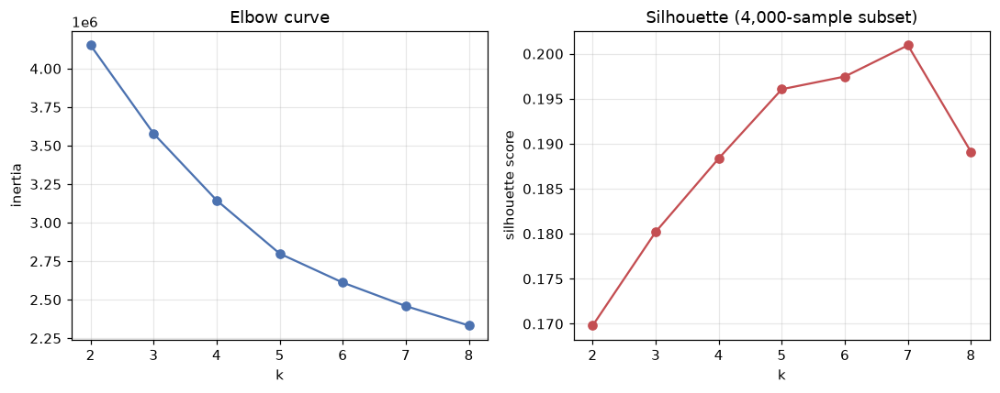

Both curves are smooth with no sharp knee -- expected, since k_min/k_max/sigma/beta are sampled continuously (not from discrete categories), so the embedding varies continuously too (consistent with 6.3's smooth gradients). We fix k=5 below purely to give the continuum some interpretable, coarse-grained labels ('regimes'), not because 5 true clusters exist.


In [40]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

X = interp_df[pc_cols].values
rng = np.random.default_rng(0)
sub_idx = rng.choice(len(X), size=4000, replace=False)

k_range = range(2, 9)
inertias, silhouettes = [], []
for k in k_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=0).fit(X[sub_idx])
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X[sub_idx], km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(list(k_range), inertias, marker="o", color="#4C72B0")
axes[0].set_xlabel("k")
axes[0].set_ylabel("inertia")
axes[0].set_title("Elbow curve")
axes[1].plot(list(k_range), silhouettes, marker="o", color="#C44E52")
axes[1].set_xlabel("k")
axes[1].set_ylabel("silhouette score")
axes[1].set_title("Silhouette (4,000-sample subset)")
plt.tight_layout()
plt.show()

print(
    "Both curves are smooth with no sharp knee -- expected, since k_min/k_max/sigma/beta are "
    "sampled continuously (not from discrete categories), so the embedding varies continuously "
    "too (consistent with 6.3's smooth gradients). We fix k=5 below purely to give the continuum "
    "some interpretable, coarse-grained labels ('regimes'), not because 5 true clusters exist."
)

In [41]:
N_CLUSTERS = 5
km_final = KMeans(n_clusters=N_CLUSTERS, n_init=10, random_state=0).fit(X)

interp_df["cluster_raw"] = km_final.labels_
cluster_beta_order = interp_df.groupby("cluster_raw")["truth_beta"].mean().sort_values().index
relabel = {old: new for new, old in enumerate(cluster_beta_order)}
interp_df["cluster"] = interp_df["cluster_raw"].map(relabel)
interp_df = interp_df.drop(columns="cluster_raw")

cluster_summary = interp_df.groupby("cluster")[[f"truth_{t}" for t in TARGETS]].agg(["mean", "std"])
cluster_summary["n"] = interp_df.groupby("cluster").size()
cluster_summary

truth_k_min           truth_k_max           truth_sigma            \
               mean       std        mean       std        mean       std   
cluster                                                                     
0         15.660378  8.254373   50.822017  7.618038    2.622560  1.357855   
1         17.272945  8.814510   37.565944  2.237583    2.564563  1.359506   
2         18.255636  8.304802   51.895606  6.982251    0.709800  0.455268   
3          6.270348  3.246001   52.516098  6.812275    3.021894  1.142038   
4         22.970034  5.502699   52.911783  6.449560    3.387017  0.964362   

        truth_beta                n  
              mean       std         
cluster                              
0        -2.752232  0.182172   9131  
1        -1.913788  0.537607  10607  
2        -1.850845  0.495642   9624  
3        -1.789122  0.464066   8841  
4        -1.769151  0.467801  11797

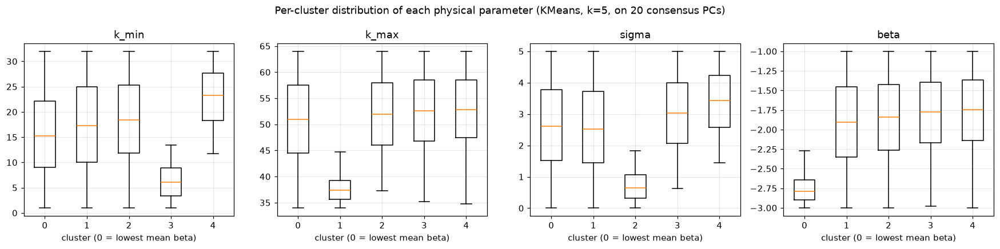

Clusters are ordered by ascending mean beta. Read these as coarse bins along a continuous manifold (see 6.4's elbow/silhouette scan above) rather than physically distinct populations -- useful for a discrete 'regime' vocabulary, not evidence of true sub-populations in the data.


In [42]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
clusters_sorted = sorted(interp_df["cluster"].unique())
for ax, target in zip(axes, TARGETS):
    data = [interp_df.loc[interp_df["cluster"] == c, f"truth_{target}"] for c in clusters_sorted]
    ax.boxplot(data, showfliers=False)
    ax.set_xticks(range(1, len(clusters_sorted) + 1))
    ax.set_xticklabels(clusters_sorted)
    ax.set_title(target)
    ax.set_xlabel("cluster (0 = lowest mean beta)")
fig.suptitle(f"Per-cluster distribution of each physical parameter (KMeans, k={N_CLUSTERS}, on {n_pcs} consensus PCs)")
plt.tight_layout()
plt.show()

print(
    "Clusters are ordered by ascending mean beta. Read these as coarse bins along a continuous "
    "manifold (see 6.4's elbow/silhouette scan above) rather than physically distinct populations -- "
    "useful for a discrete 'regime' vocabulary, not evidence of true sub-populations in the data."
)

### 6.5 Interactive embedding explorer

One interactive Plotly scatter of the consensus embedding (UMAP 2D, test split -- UMAP is used here purely as a visualization layout since it separates local structure better than any single PC pair; 6.1-6.4 above are what carry the quantitative, physically-interpretable claims). Use the dropdown to tint by any of the four targets or by the 6.4 cluster label.

Requires `plotly`, which isn't currently a `turbulens` dependency (this notebook already relies on `pandas`, also not in `pyproject.toml`, so it's evidently run against a research kernel with more packages installed than the packaged library needs) -- `pip install plotly` into that kernel if this errors.

In [43]:
!pip install --upgrade nbformat


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: C:\Users\sedig\AppData\Local\Programs\Python\Python312\python.exe -m pip install --upgrade pip


In [44]:
import plotly.graph_objects as go

color_options = TARGETS + ["cluster"]
default = "beta"

hover_text = [
    f"sample: {key}<br>" + "<br>".join(f"{t}: {v:.3f}" for t, v in zip(TARGETS, row))
    for key, row in zip(interp_df["sample_key"], interp_df[[f"truth_{t}" for t in TARGETS]].values)
]

fig = go.Figure()
fig.add_trace(go.Scattergl(
    x=interp_df["UMAP1"], y=interp_df["UMAP2"],
    mode="markers",
    marker=dict(
        size=4, opacity=0.6,
        color=interp_df[f"truth_{default}"],
        colorscale="Viridis",
        colorbar=dict(title=dict(text=default)),
        cmin=float(interp_df[f"truth_{default}"].min()),
        cmax=float(interp_df[f"truth_{default}"].max()),
    ),
    text=hover_text,
    hoverinfo="text",
))

buttons = []
for opt in color_options:
    if opt == "cluster":
        vals = interp_df["cluster"].astype(float)
        colorscale = "Turbo"
    else:
        vals = interp_df[f"truth_{opt}"]
        colorscale = "Viridis"
    buttons.append(dict(
        label=opt,
        method="restyle",
        args=[{
            "marker.color": [vals],
            "marker.colorscale": [colorscale],
            "marker.cmin": [float(vals.min())],
            "marker.cmax": [float(vals.max())],
            "marker.colorbar.title.text": [opt],
        }],
    ))

fig.update_layout(
    title="Consensus embedding (UMAP 2D, test split) -- color by true parameter or cluster",
    xaxis_title="UMAP1", yaxis_title="UMAP2",
    updatemenus=[dict(buttons=buttons, direction="down", x=1.15, y=1.0, xanchor="left")],
    width=850, height=650,
)
fig.show()

## 7. Real observations: `turbulens infer --real-data` on GASS HI cubes

Running the actual `turbulens` inference package (Python API, equivalent to the CLI's `turbulens infer --method cnn --real-data`) against the four real GASS survey cubes bundled in `observational_images/`, and comparing against the classical `--method fft-powerlaw` estimator as an independent cross-check. See `docs/turbulens/concepts.rst` for why `--real-data` is needed at all (training images are log-density; real maps are on a completely different linear scale).

In [45]:
import sys

sys.path.insert(0, str(PROJECT_ROOT))

from turbulens.inference import Inferencer
from turbulens.io.image_loaders import load_input
from turbulens.models.registry import EnsembleRegistry
from turbulens.spectral import SpectralEstimator

members_dir = EnsembleRegistry.resolve(PROJECT_ROOT / "outputs")
inferencer = Inferencer(members_dir)
print(f"Loaded {len(member_dirs)}-member ensemble from {members_dir}")

gass_files = sorted((PROJECT_ROOT / "observational_images").glob("gass_*.fits.gz"))
[p.name for p in gass_files]

Loaded 5-member ensemble from c:\Users\sedig\Documents\cnn-turbulence\outputs\multitask\local_v2\ensemble\members


['gass_0_-10_1774394180.fits.gz',
 'gass_0_0_1774393774.fits.gz',
 'gass_300_14_1774393529.fits.gz',
 'gass_314_-28_1774393621.fits.gz']

In [46]:
rows = []
with warnings.catch_warnings():
    # Astropy FITSFixedWarning (harmless WCS unit/CTYPE normalization) and the
    # out-of-distribution clip warning (expected without --real-data) are suppressed
    # here purely for clean notebook output; nothing above is silently skipped.
    warnings.simplefilter("ignore")
    for path in gass_files:
        cube = load_input(path, hdu=0)
        image_cube = cube.project(0, cube.n_channels)  # full velocity-axis integration
        cnn_table = inferencer.predict(image_cube.data, real_data=True)
        fft_table = SpectralEstimator(method="power_law").predict(image_cube.data)

        row = {"cube": path.name}
        for r in cnn_table:
            row[f"cnn_{r['target']}"] = r["value"]
            row[f"cnn_{r['target']}_std"] = r["epistemic_std"]
        row["clipped_pixel_fraction_max"] = cnn_table.meta["clipped_pixel_fraction_max"]
        for r in fft_table:
            row[f"fft_{r['target']}"] = r["value"]
        rows.append(row)

gass_df = pd.DataFrame(rows).set_index("cube")
gass_df

,cnn_k_min,cnn_k_min_std,cnn_k_max,cnn_k_max_std,cnn_sigma,cnn_sigma_std,cnn_beta,cnn_beta_std,clipped_pixel_fraction_max,fft_k_min,fft_k_max,fft_alpha,fft_r_squared
cube,,,,,,,,,,,,,
gass_0_-10_1774394180.fits.gz,1.459203,0.595217,63.755329,0.191869,4.184161,0.108189,-2.713313,0.143341,0.000000,1.0,61.0,-2.929016,0.997493
gass_0_0_1774393774.fits.gz,1.379210,0.525735,63.909809,0.157963,4.141920,0.117058,-2.528721,0.123154,0.001152,2.0,61.0,-4.023438,0.995909
gass_300_14_1774393529.fits.gz,1.609420,0.593302,63.222649,0.568277,4.191220,0.056282,-2.713978,0.091623,0.000000,1.0,61.0,-2.963670,0.995150
gass_314_-28_1774393621.fits.gz,1.516129,0.563953,63.534821,0.204377,3.587663,0.078083,-2.708540,0.091151,0.000000,2.0,61.0,-3.703045,0.993800


**What the error bars show:** `epistemic_std` (plotted as `yerr` on the CNN bars below) is the standard deviation of the 5 ensemble members' individual physical-unit predictions for that cube (`ddof=1`) -- i.e. member-to-member disagreement about that specific real image, not a measurement uncertainty or a per-image confidence interval on the true physical parameter. `Inferencer.predict` (`turbulens/inference.py`) denormalizes each member independently before averaging, so this is a real member-to-member spread in physical units, not an artifact of averaging normalized outputs.

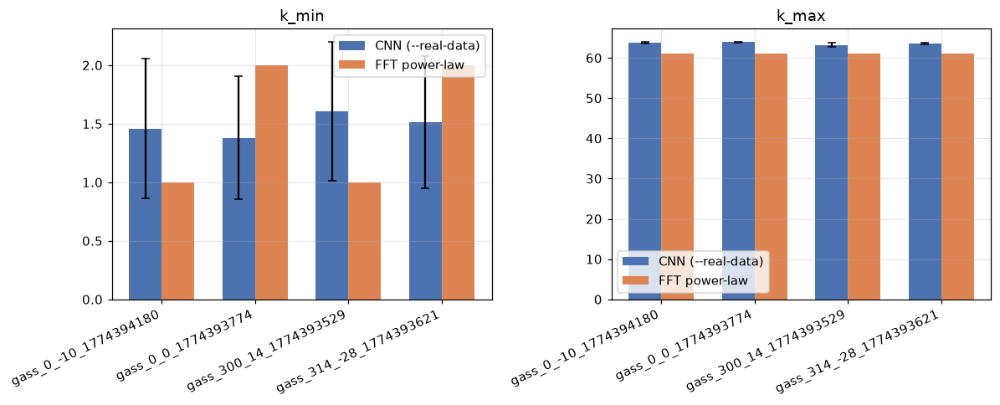

clipped_pixel_fraction_max per cube (all should sit near ~1%, the expected floor under
--real-data's 0.5/99.5 percentile self-normalization, well below the 5% OOD warning threshold):
cube
gass_0_-10_1774394180.fits.gz      0.000000
gass_0_0_1774393774.fits.gz        0.001152
gass_300_14_1774393529.fits.gz     0.000000
gass_314_-28_1774393621.fits.gz    0.000000
Name: clipped_pixel_fraction_max, dtype: float64


In [47]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
x = np.arange(len(gass_df))
width = 0.35
labels = [c.replace(".fits.gz", "") for c in gass_df.index]

for ax, target in zip(axes, ["k_min", "k_max"]):
    ax.bar(
        x - width / 2, gass_df[f"cnn_{target}"], width,
        yerr=gass_df[f"cnn_{target}_std"], label="CNN (--real-data)", color="#4C72B0", capsize=3,
    )
    ax.bar(x + width / 2, gass_df[f"fft_{target}"], width, label="FFT power-law", color="#DD8452")
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=25, ha="right")
    ax.set_title(target)
    ax.legend()
plt.tight_layout()
plt.show()

print("clipped_pixel_fraction_max per cube (all should sit near ~1%, the expected floor under")
print("--real-data's 0.5/99.5 percentile self-normalization, well below the 5% OOD warning threshold):")
print(gass_df["clipped_pixel_fraction_max"])

**Caveats** (see `docs/turbulens/concepts.rst` "Running on real observations" and `docs/THESIS_CONTEXT.md` §7 for the full discussion):

- No ground truth exists for these real cubes -- this is a cross-method consistency check (CNN vs. independent classical estimator), not an accuracy measurement.
- `k_max` lands at the FFT grid edge (~61-64 of a 62-pixel Nyquist limit for these 125x125 images) for every cube -- an image-resolution limitation, not a method failure.
- `--real-data` only fixes the pixel-intensity-scale mismatch (log10 + self-normalization); it does not address training images being single mid-plane slices vs. real line-of-sight-integrated column density. Treat these CNN predictions as exploratory.

## 8. Multitask vs. single-target comparison

Everything above evaluates the shared multitask ensemble on its own. The training pipeline also produced four dedicated single-target ensembles (one `ResNet` per target, same 5-member/seed protocol) and ran `turbulens/training/compare_multitask_single.py` between them and the multitask ensemble on identical held-out test sample keys -- this asks whether sharing one backbone across all four targets actually costs anything in accuracy, and if so, whether it is worth what it saves in training cost.

In [48]:
COMPARISON_ROOT = PROJECT_ROOT / "outputs" / "comparison" / "local_v2"

metrics_by_target = pd.read_csv(COMPARISON_ROOT / "metrics_by_target.csv")
test_metrics = metrics_by_target.set_index(["target", "approach"])

comparison_table = test_metrics[["mae", "rmse", "r2", "pearson"]]
comparison_table.columns = ["MAE", "RMSE", "R2", "Pearson"]
comparison_table = comparison_table.reindex(TARGETS, level="target")
comparison_table

MAE      RMSE        R2   Pearson
target approach                                             
k_min  multitask      0.119058  0.152804  0.999710  0.999856
       single_target  0.066977  0.089312  0.999901  0.999950
k_max  multitask      0.602372  1.238747  0.979488  0.989866
       single_target  0.427135  1.085511  0.984249  0.992098
sigma  multitask      0.033855  0.045238  0.999013  0.999557
       single_target  0.027837  0.039614  0.999243  0.999625
beta   multitask      0.111308  0.163114  0.920336  0.959616
       single_target  0.122905  0.175259  0.908031  0.953219

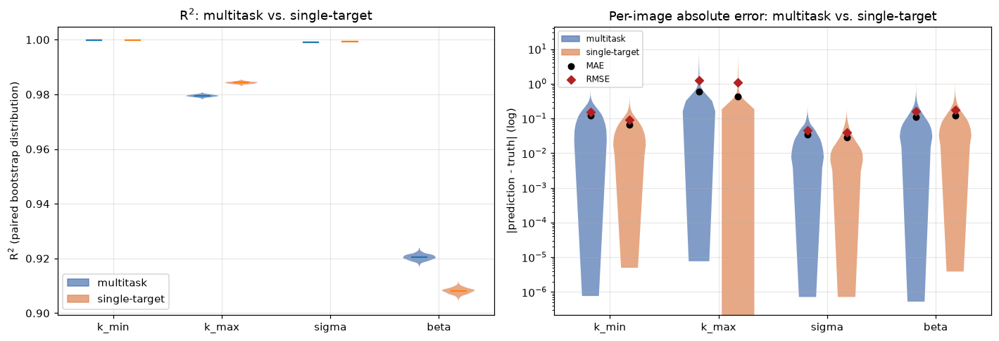

Even the dedicated single-target beta model only reaches R2=0.908 (multitask: 0.920) -- a whole network trained on beta alone, with no other targets to share capacity with, still falls well short of k_min/sigma's ~0.999. That points to a data/signal ceiling for beta (see 8.3's interpretation) rather than a cost specifically imposed by joint regression.


In [54]:
def paired_bootstrap_r2(truth, pred_a, pred_b, n_boot=1000, seed=0):
    """Bootstrap R2 for two approaches using the SAME resampled indices each draw,
    so the comparison isn't confounded by independent resampling noise."""
    truth = np.asarray(truth)
    pred_a = np.asarray(pred_a)
    pred_b = np.asarray(pred_b)
    n = len(truth)
    rng = np.random.default_rng(seed)
    boot_a = np.empty(n_boot)
    boot_b = np.empty(n_boot)
    for i in range(n_boot):
        idx = rng.integers(0, n, n)
        t = truth[idx]
        ss_tot = np.sum((t - t.mean()) ** 2)
        boot_a[i] = 1.0 - np.sum((t - pred_a[idx]) ** 2) / ss_tot
        boot_b[i] = 1.0 - np.sum((t - pred_b[idx]) ** 2) / ss_tot
    return boot_a, boot_b


r2_boot_multitask, r2_boot_single = {}, {}
abs_err_multitask, abs_err_single = {}, {}
mae_multitask, mae_single, rmse_multitask, rmse_single = {}, {}, {}, {}

for i, target in enumerate(TARGETS):
    single_path = (
        PROJECT_ROOT / "outputs" / f"single_{target}" / "local_v2" / "ensemble"
        / "evaluation" / "predictions" / "test_per_image_predictions.csv"
    )
    single_pred = pd.read_csv(single_path)[["sample_key", f"ensemble_mean_{target}"]].rename(
        columns={f"ensemble_mean_{target}": "pred_single"}
    )
    merged = predictions[["sample_key", f"truth_{target}", f"ensemble_mean_{target}"]].merge(
        single_pred, on="sample_key",
    )
    truth = merged[f"truth_{target}"].values
    pred_m = merged[f"ensemble_mean_{target}"].values
    pred_s = merged["pred_single"].values

    boot_m, boot_s = paired_bootstrap_r2(truth, pred_m, pred_s, seed=100 + i)
    r2_boot_multitask[target], r2_boot_single[target] = boot_m, boot_s

    # MAE and RMSE are two different aggregations (mean vs. root-mean-square) of this
    # SAME per-image quantity -- so both panels below are computed straight from it,
    # not from a bootstrap resample of the aggregate statistic.
    err_m = np.abs(truth - pred_m)
    err_s = np.abs(truth - pred_s)
    abs_err_multitask[target], abs_err_single[target] = err_m, err_s
    mae_multitask[target], mae_single[target] = err_m.mean(), err_s.mean()
    rmse_multitask[target] = np.sqrt(np.mean(err_m ** 2))
    rmse_single[target] = np.sqrt(np.mean(err_s ** 2))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

x = np.arange(len(TARGETS))
offset, vwidth = 0.18, 0.3
approach_handles = [
    plt.Rectangle((0, 0), 1, 1, color="#4C72B0", alpha=0.7),
    plt.Rectangle((0, 0), 1, 1, color="#DD8452", alpha=0.7),
]

# --- R2: paired bootstrap distribution ---
parts_m = axes[0].violinplot(
    [r2_boot_multitask[t] for t in TARGETS], positions=x - offset, widths=vwidth,
    showmeans=True, showextrema=False,
)
for pc in parts_m["bodies"]:
    pc.set_facecolor("#4C72B0")
    pc.set_alpha(0.7)
parts_s = axes[0].violinplot(
    [r2_boot_single[t] for t in TARGETS], positions=x + offset, widths=vwidth,
    showmeans=True, showextrema=False,
)
for pc in parts_s["bodies"]:
    pc.set_facecolor("#DD8452")
    pc.set_alpha(0.7)
axes[0].set_xticks(x)
axes[0].set_xticklabels(TARGETS)
axes[0].set_ylabel("R$^2$ (paired bootstrap distribution)")
axes[0].set_title("R$^2$: multitask vs. single-target")
axes[0].legend(handles=approach_handles, labels=["multitask", "single-target"], loc="lower left")

# --- MAE/RMSE: actual per-image absolute-error distribution, not a bootstrap of the
# aggregate -- MAE and RMSE are just its mean and its root-mean-square, marked on top ---
parts_m2 = axes[1].violinplot(
    [abs_err_multitask[t] for t in TARGETS], positions=x - offset, widths=vwidth,
    showmeans=False, showextrema=False,
)
for pc in parts_m2["bodies"]:
    pc.set_facecolor("#4C72B0")
    pc.set_alpha(0.7)
parts_s2 = axes[1].violinplot(
    [abs_err_single[t] for t in TARGETS], positions=x + offset, widths=vwidth,
    showmeans=False, showextrema=False,
)
for pc in parts_s2["bodies"]:
    pc.set_facecolor("#DD8452")
    pc.set_alpha(0.7)
for i, target in enumerate(TARGETS):
    axes[1].scatter(
        [x[i] - offset, x[i] + offset], [mae_multitask[target], mae_single[target]],
        marker="o", color="black", zorder=3, s=30, label="MAE" if i == 0 else None,
    )
    axes[1].scatter(
        [x[i] - offset, x[i] + offset], [rmse_multitask[target], rmse_single[target]],
        marker="D", color="firebrick", zorder=3, s=30, label="RMSE" if i == 0 else None,
    )
axes[1].set_yscale("log")
axes[1].set_xticks(x)
axes[1].set_xticklabels(TARGETS)
axes[1].set_ylabel("|prediction - truth| (log)")
axes[1].set_title("Per-image absolute error: multitask vs. single-target")
handles1, labels1 = axes[1].get_legend_handles_labels()
axes[1].legend(handles=approach_handles + handles1, labels=["multitask", "single-target"] + labels1, loc="upper left", fontsize=8)

plt.tight_layout()
plt.show()

print(
    f"Even the dedicated single-target beta model only reaches R2={r2_boot_single['beta'].mean():.3f} "
    f"(multitask: {r2_boot_multitask['beta'].mean():.3f}) -- a whole network trained on beta alone, "
    "with no other targets to share capacity with, still falls well short of k_min/sigma's ~0.999. "
    "That points to a data/signal ceiling for beta (see 8.3's interpretation) rather than a cost "
    "specifically imposed by joint regression."
)

### 8.1 Is the difference real?

`metrics_by_target.csv` above averages across independently trained ensemble members and can make small, real per-image differences hard to read. `paired_comparisons.csv` instead runs a paired randomization test on the per-image absolute error, on identical test sample keys, with Holm-Bonferroni correction across the four targets -- the right test for "does switching from one architecture to the other change accuracy on the same images", as opposed to "do the mean metrics differ".

In [50]:
paired = pd.read_csv(COMPARISON_ROOT / "paired_comparisons.csv")
paired_summary = paired[paired["metric"] == "paired_absolute_error_mean"].set_index("target")
paired_summary = paired_summary.reindex(TARGETS)[[
    "difference_single_minus_multitask", "interpretation",
    "permutation_p_value", "holm_adjusted_p_value_across_targets",
]]
paired_summary.columns = ["single - multitask (MAE)", "interpretation", "p-value", "Holm-adjusted p-value"]
paired_summary

,single - multitask (MAE),interpretation,p-value,Holm-adjusted p-value
target,,,,
k_min,-0.052081,negative favors single-target,0.0001,0.0004
k_max,-0.175237,negative favors single-target,0.0001,0.0004
sigma,-0.006019,negative favors single-target,0.0001,0.0004
beta,0.011597,negative favors single-target,0.0001,0.0004


### 8.2 What does the accuracy edge cost?

The single-target system is four independently trained networks, one per target, against one shared network for the multitask ensemble -- so any accuracy edge has to be weighed against training and inference cost, not just read off the metrics above.

In [51]:
cost = pd.read_csv(COMPARISON_ROOT / "computational_cost.csv")
cost_display = cost.set_index(["approach", "target"])[[
    "parameter_count_trainable_mean", "training_seconds_mean", "test_inference_seconds_mean",
]]
cost_display.columns = ["trainable params", "training time (s/member)", "test inference time (s)"]
cost_display

trainable params  \
approach             target                              
multitask            all                    21779268.0   
single_target        k_min                  24708481.0   
                     k_max                  24714753.0   
                     sigma                  11590529.0   
                     beta                   24708481.0   
single_target_system all_four_models        85722244.0   

                                      training time (s/member)  \
approach             target                                      
multitask            all                           6463.429021   
single_target        k_min                        11794.674147   
                     k_max                        11597.700733   
                     sigma                         2478.475279   
                     beta                          8425.112626   
single_target_system all_four_models                       NaN   

                                      test inference time (s)  
approach             target                                    
multitask            all                             7.255936  
single_target        k_min                          12.174373  
                     k_max                          12.657747  
                     sigma                           4.073088  
                     beta                           13.720767  
single_target_system all_four_models                42.625975

### 8.3 Interpretation

Single-target models are statistically significantly ahead of the multitask ensemble on `k_min`, `k_max`, and `sigma` (Holm-adjusted p < 0.001 on the paired test), but the effect size is small in physical units (MAE differences of roughly 0.05-0.18 across those three targets). On `beta` the relationship reverses and the multitask ensemble is significantly better. The single-target system also costs roughly 5x the total training time and 4x the trainable parameters of one shared multitask model (`single_target_system` row above), since it trains one full network per target rather than sharing a backbone.

Net: joint regression is not a free lunch -- it gives up a small, real amount of accuracy on three of the four targets relative to dedicated models -- but it is the clearly better choice on `beta` (the hardest target), and it gets all four targets from one model at a fraction of the training cost of the single-target alternative. See `turbulens/models/architecture.py`'s module docstring for how this shapes the default architecture choice, and `outputs/comparison/local_v2/comparison_report.md` for the full report.

## 9. Summary

- The `local_v2` multitask ensemble (ResNet-34, 5 members, 100k/20k/50k train/val/test) recovers `k_min` and `sigma` almost perfectly (R² = 0.9997 and 0.9990) and `k_max` at R² = 0.9795 -- consistent with the earlier `local_v1` ensemble and confirming the pyFC spectral-cutoff fix (`docs/bugs/pyfc-kmax-not-enforced.md`) continues to hold under the refined `local_v2` search (refined grid, architecture reselected from ResNet-18 to ResNet-34, see `turbulens/training/docs/GRID_REFINEMENT_RATIONALE.md`).
- The multitask ensemble is not a free lunch: dedicated single-target models are statistically significantly (but only marginally, in physical units) ahead on `k_min`, `k_max`, and `sigma`, while multitask is significantly better on `beta` and costs ~5x less to train than the four-model single-target system (Section 8).
- `beta` remains the comparatively weakest target (R² = 0.920), essentially unchanged from `local_v1` -- still no dedicated root-cause investigation, still a natural next step.
- Epistemic spread's correlation with actual error is target-dependent, not uniformly positive: `k_max` (corr = 0.58) and `beta` (corr = 0.44) show a clear positive relationship, `sigma` a weaker one (corr = 0.24), and `k_min` essentially none (corr = 0.02) -- likely because `k_min` errors are already tiny and near-floor across members, leaving little spread left to be informative. Epistemic spread is therefore a useful per-prediction trust signal for `k_max`/`beta`, but not for `k_min`.
- The learned shared representation organizes strongly by the true physical parameters, and does so almost one-axis-per-parameter: PC1↔`sigma` (r=0.93), PC2↔`k_min` (r=-0.93), PC3↔`beta` (r=-0.88), PC4↔`k_max` (r=-0.94), together explaining 72.6% of the 20-component consensus PCA's variance -- plus CCA canonical correlations of 0.95-0.99 across all four components on held-out test data. This is strong evidence the network isn't just curve-fitting the labels but has learned a physically structured, largely disentangled embedding. KMeans clustering of that embedding shows no natural cluster count (smooth elbow/silhouette curves) -- expected, since the four parameters are sampled continuously, not categorically -- so any fixed-`k` "regime" labeling is a coarse-graining convenience, not evidence of true sub-populations.
- Running the same ensemble on real GASS HI data via `turbulens infer --real-data` gives `k_min`/`k_max` broadly consistent with an independent classical estimator, a reassuring sanity check given the CNN never saw anything resembling real column-density data during training -- but `sigma`/`beta` on real data remain unvalidated against any ground truth.